# Exploratory Data Analysis (EDA) for Bank Marketing Dataset

In [127]:
!uv add pandas seaborn scikit-learn

Resolved 20 packages in 0.47ms
Audited 19 packages in 0.04ms


In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Load Dataset

In [ ]:
# !curl -L -o ../data/bank-marketing.zip https://www.kaggle.com/api/v1/datasets/download/dhirajnirne/bank-marketing
# !unzip ../data/bank-marketing.zip -d ../data

In [3]:
df = pd.read_csv("../data/bank-marketing.csv")
df.head()

,age,age group,eligible,job,salary,marital,education,marital-education,targeted,default,...,contact,day,month,duration,campaign,pdays,previous,poutcome,y,response
0,58,5,Y,management,100000,married,tertiary,married-tertiary,yes,no,...,unknown,5,may,261,1,-1,0,unknown,no,0
1,44,4,Y,technician,60000,single,secondary,single-secondary,yes,no,...,unknown,5,may,151,1,-1,0,unknown,no,0
2,33,3,Y,entrepreneur,120000,married,secondary,married-secondary,yes,no,...,unknown,5,may,76,1,-1,0,unknown,no,0
3,47,4,Y,blue-collar,20000,married,unknown,married-unknown,no,no,...,unknown,5,may,92,1,-1,0,unknown,no,0
4,33,3,Y,unknown,0,single,unknown,single-unknown,no,no,...,unknown,5,may,198,1,-1,0,unknown,no,0


## Overview

In [5]:
print(f"Daset shape: {df.shape}")

Daset shape: (45211, 23)


In [13]:
print("--- Basic info ---")
df.info()

--- Basic info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 23 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   age                45211 non-null  int64 
 1   age group          45211 non-null  int64 
 2   eligible           45211 non-null  object
 3   job                45211 non-null  object
 4   salary             45211 non-null  int64 
 5   marital            45211 non-null  object
 6   education          45211 non-null  object
 7   marital-education  45211 non-null  object
 8   targeted           45211 non-null  object
 9   default            45211 non-null  object
 10  balance            45211 non-null  int64 
 11  housing            45211 non-null  object
 12  loan               45211 non-null  object
 13  contact            45211 non-null  object
 14  day                45211 non-null  int64 
 15  month              45211 non-null  object
 16  duration           45

In [11]:
print("--- Statistical Summary ---")
df.describe(include='all')

--- Statistical Summary ---


,age,age group,eligible,job,salary,marital,education,marital-education,targeted,default,...,contact,day,month,duration,campaign,pdays,previous,poutcome,y,response
count,45211.000000,45211.000000,45211,45211,45211.000000,45211,45211,45211,45211,45211,...,45211,45211.000000,45211,45211.000000,45211.000000,45211.000000,45211.000000,45211,45211,45211.000000
unique,NaN,NaN,2,12,NaN,3,4,12,2,2,...,3,NaN,12,NaN,NaN,NaN,NaN,4,2,NaN
top,NaN,NaN,Y,blue-collar,NaN,married,secondary,married-secondary,yes,no,...,cellular,NaN,may,NaN,NaN,NaN,NaN,unknown,no,NaN
freq,NaN,NaN,43380,9732,NaN,27214,23202,13770,37091,44396,...,29285,NaN,13766,NaN,NaN,NaN,NaN,36959,39922,NaN
mean,40.936210,3.645861,NaN,NaN,57006.171065,NaN,NaN,NaN,NaN,NaN,...,NaN,15.806419,NaN,258.163080,2.763841,40.197828,0.580323,NaN,NaN,0.116985
std,10.618762,1.083271,NaN,NaN,32085.718415,NaN,NaN,NaN,NaN,NaN,...,NaN,8.322476,NaN,257.527812,3.098021,100.128746,2.303441,NaN,NaN,0.321406
min,18.000000,1.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,1.000000,NaN,0.000000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
25%,33.000000,3.000000,NaN,NaN,20000.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,8.000000,NaN,103.000000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
50%,39.000000,3.000000,NaN,NaN,60000.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,16.000000,NaN,180.000000,2.000000,-1.000000,0.000000,NaN,NaN,0.000000
75%,48.000000,4.000000,NaN,NaN,70000.000000,NaN,NaN,NaN,NaN,NaN,...,NaN,21.000000,NaN,319.000000,3.000000,-1.000000,0.000000,NaN,NaN,0.000000


In [16]:
print("--- Target Variable Distribution ---")
print(df['y'].value_counts(normalize=True))

--- Target Variable Distribution ---
y
no     0.883015
yes    0.116985
Name: proportion, dtype: float64


In [17]:
df.replace('unknown', np.nan, inplace=True)
df.isnull().sum()

age                      0
age group                0
eligible                 0
job                    288
salary                   0
marital                  0
education             1857
marital-education        0
targeted                 0
default                  0
balance                  0
housing                  0
loan                     0
contact              13020
day                      0
month                    0
duration                 0
campaign                 0
pdays                    0
previous                 0
poutcome             36959
y                        0
response                 0
dtype: int64

In [ ]:
df[["job", "education", "contact", "poutcome"]].value_counts()

job          education  contact    poutcome
management   tertiary   cellular   failure     6826
blue-collar  secondary  cellular   failure     5339
technician   secondary  cellular   failure     4899
admin.       secondary  cellular   failure     3793
blue-collar  primary    cellular   failure     3343
                                               ... 
student      primary    telephone  other          1
technician   tertiary   telephone  success        1
unemployed   secondary  telephone  success        1
             tertiary   telephone  other          1
                                   success        1
Name: count, Length: 183, dtype: int64

## Data cleaning

In [25]:
# Fill missing values
for col in ['job', 'education', 'contact', 'poutcome']:
    df[col] = df[col].fillna(df[col].mode()[0])

## Variables numéricas

In [ ]:
NUMERICAL_FEATURES = df.select_dtypes(include=[np.number]).columns.tolist()
NUMERICAL_FEATURES

['age',
 'age group',
 'salary',
 'balance',
 'day',
 'duration',
 'campaign',
 'pdays',
 'previous',
 'response']

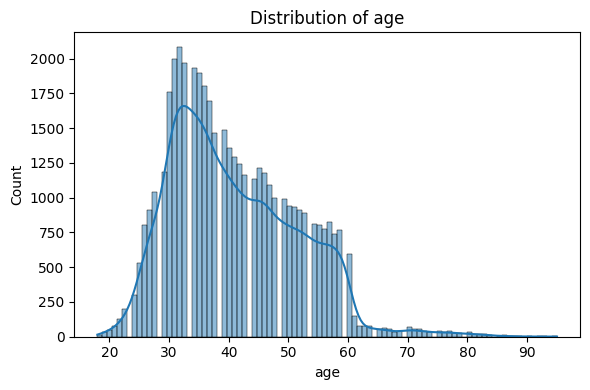

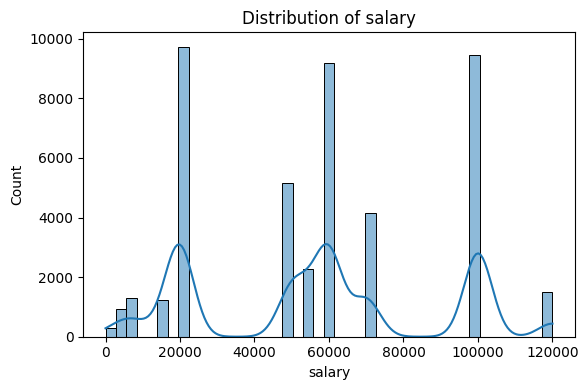

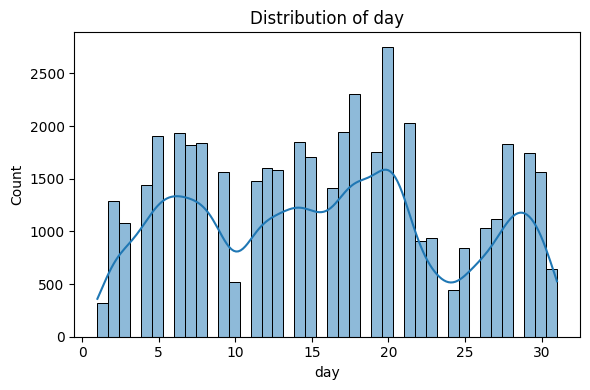

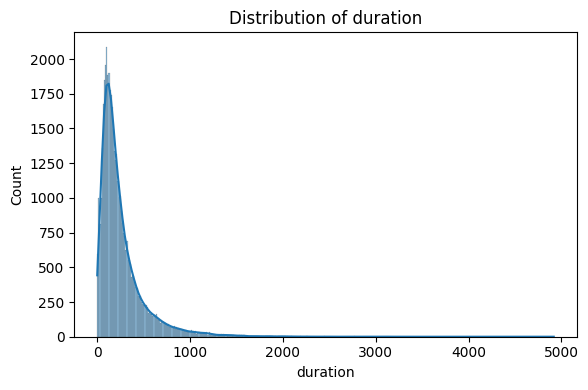

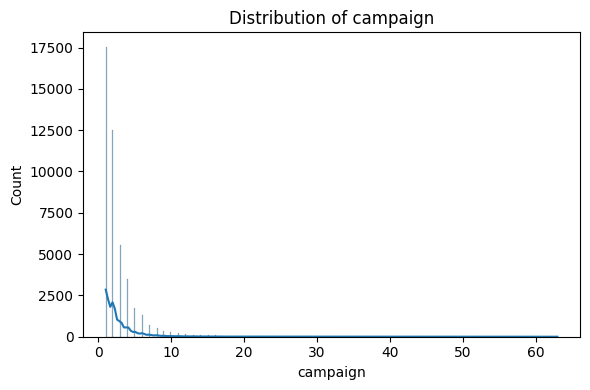

In [95]:
num_cols = ['age', 'salary', 'day', 'duration', 'campaign']
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

## Variables categóricas

In [43]:
CATEGORICAL_FEATURES = df.select_dtypes(exclude=[np.number]).columns.tolist()
CATEGORICAL_FEATURES

['eligible',
 'job',
 'marital',
 'education',
 'marital-education',
 'targeted',
 'default',
 'housing',
 'loan',
 'contact',
 'month',
 'poutcome',
 'y']

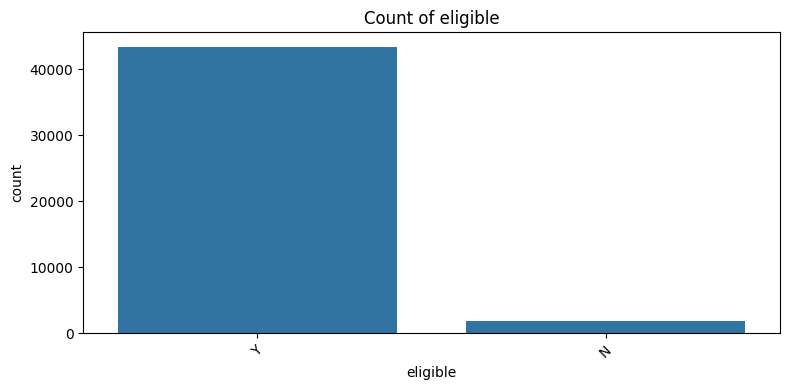

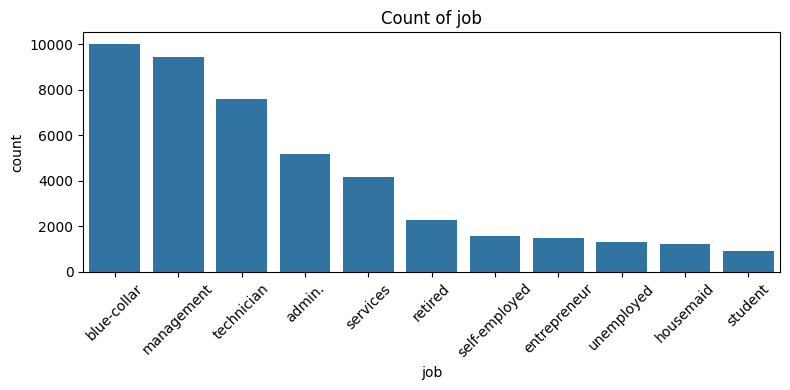

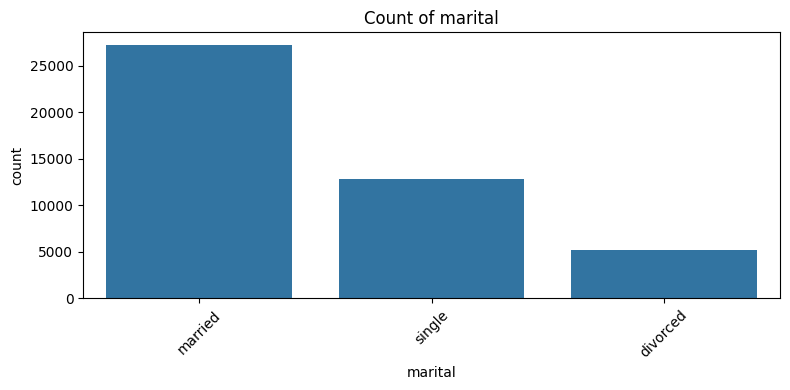

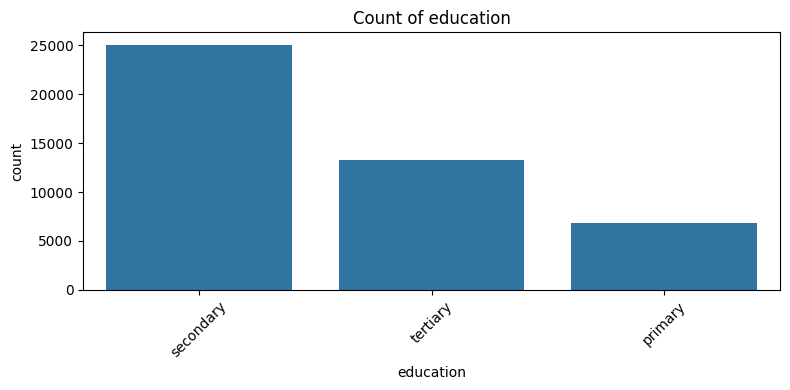

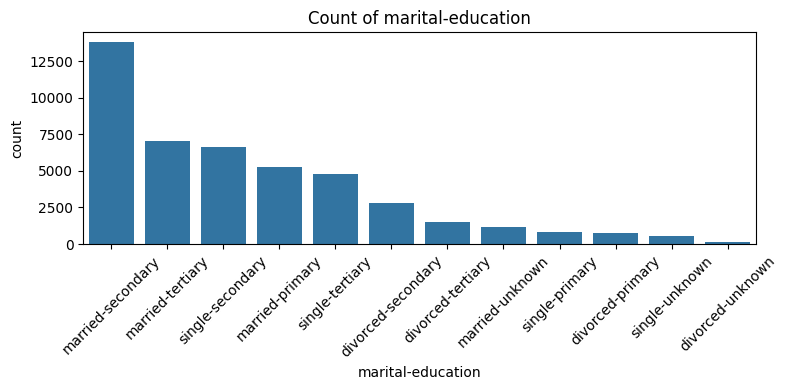

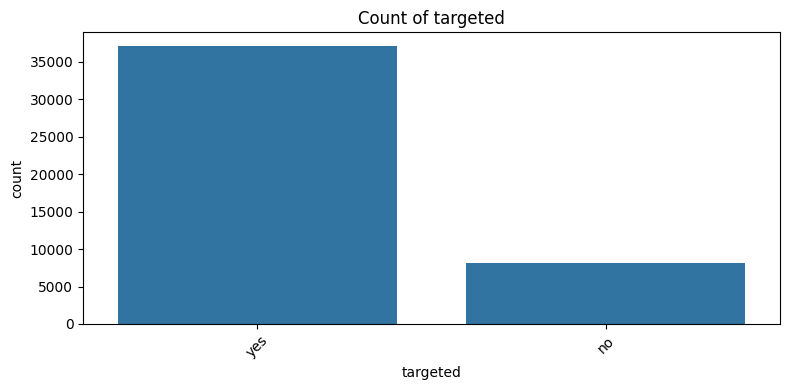

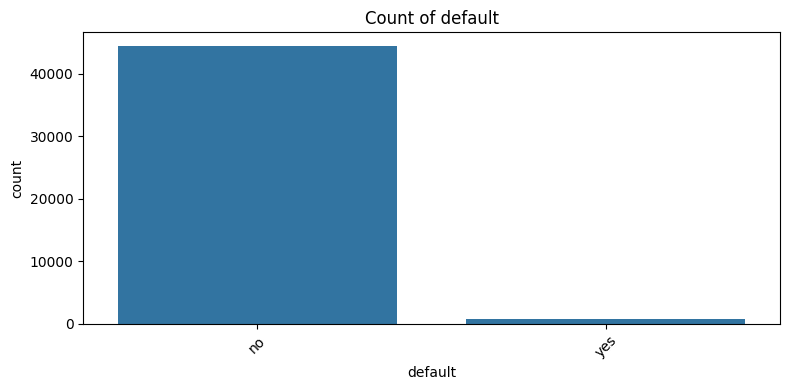

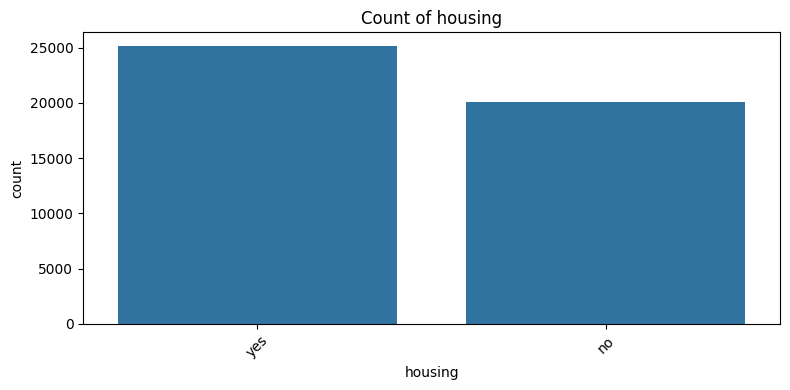

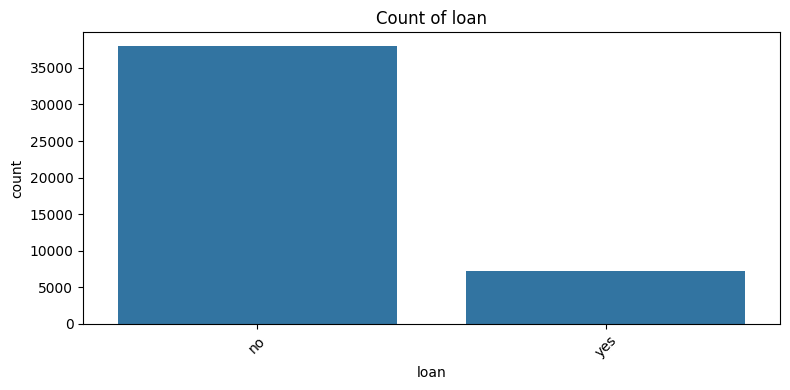

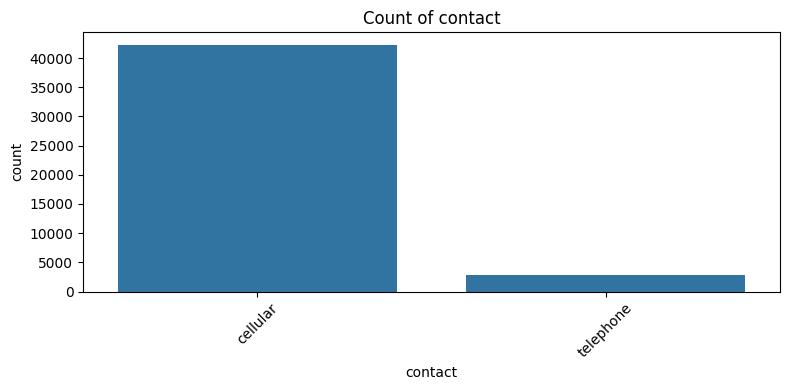

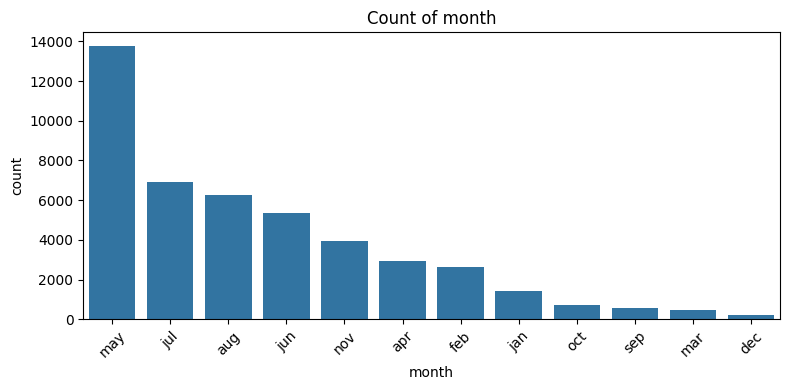

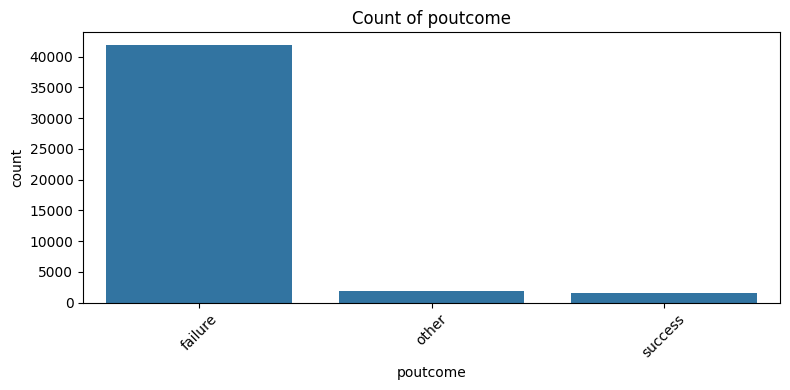

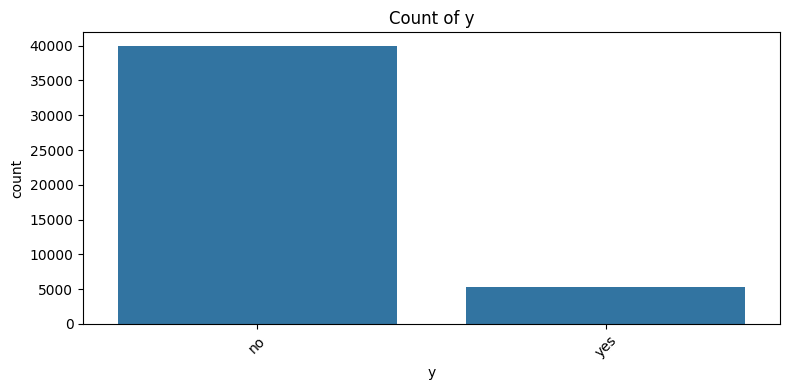

In [65]:
# Categorical variables distribution
for col in CATEGORICAL_FEATURES:
    plt.figure(figsize=(8,4))
    order = df[col].value_counts().index     # Ordenar las categorías según su frecuencia (de mayor a menor) 
    sns.countplot(x=col, data=df, order=order)
    plt.title(f'Count of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Análisis multivariado

### Numerical variables vs Target

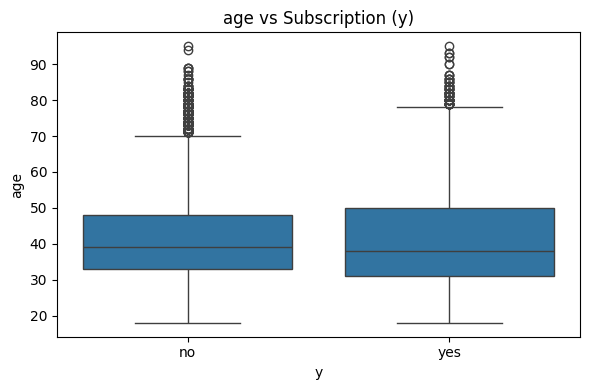

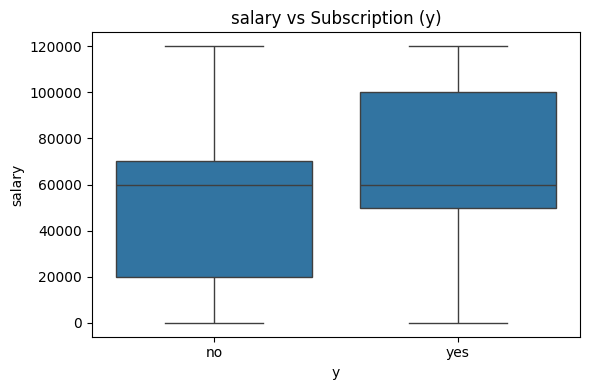

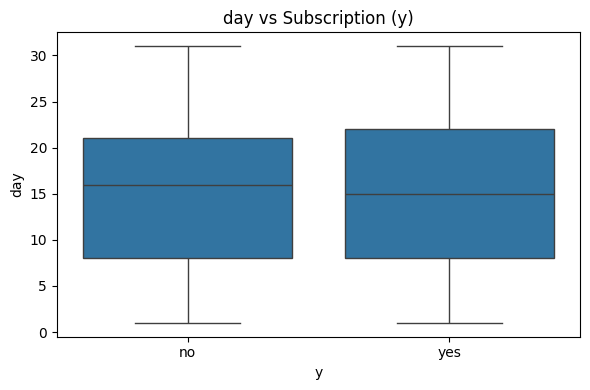

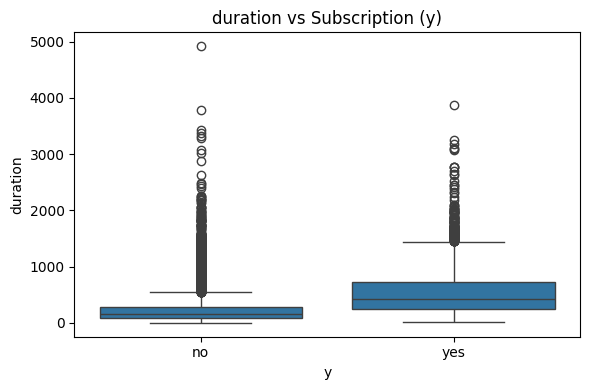

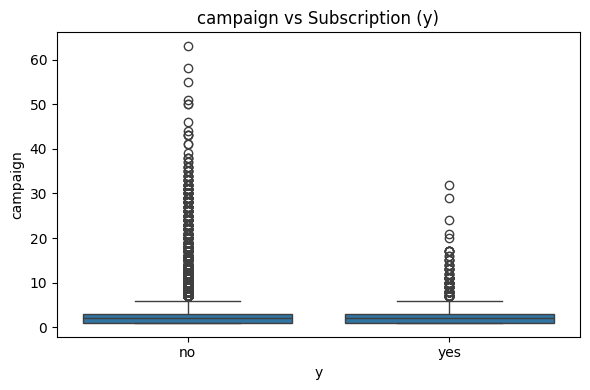

In [78]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} vs Subscription (y)')
    plt.tight_layout()
    plt.show()

### Categorical variable vs Target

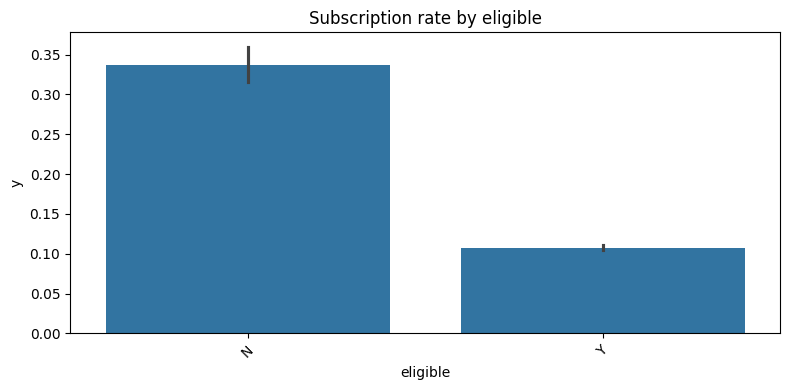

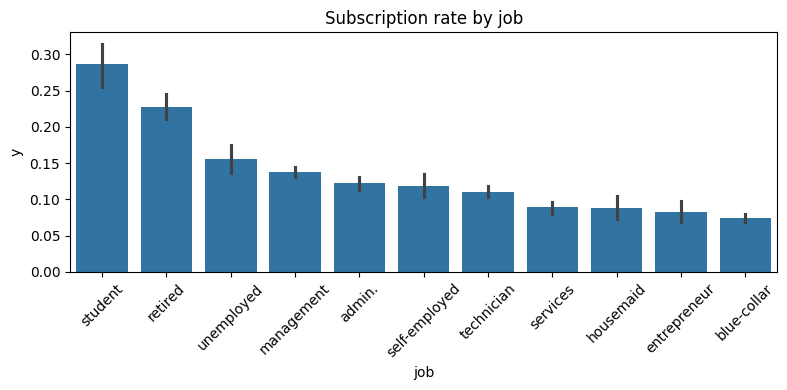

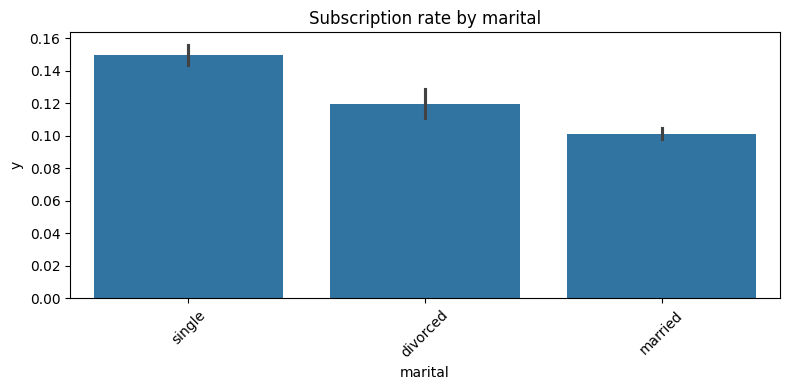

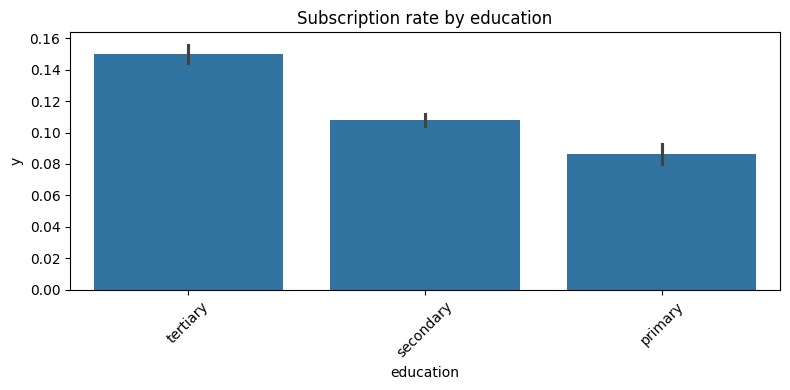

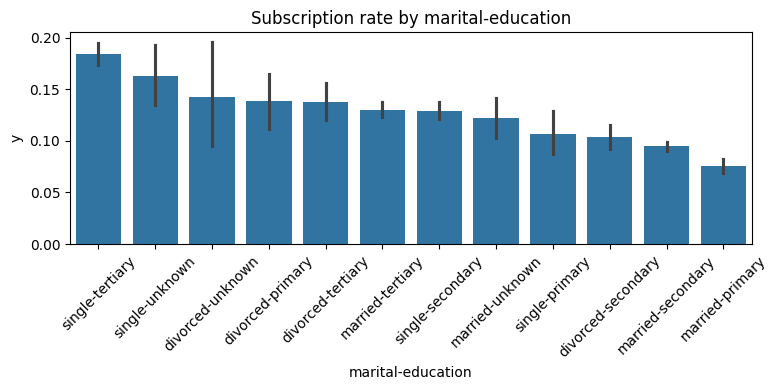

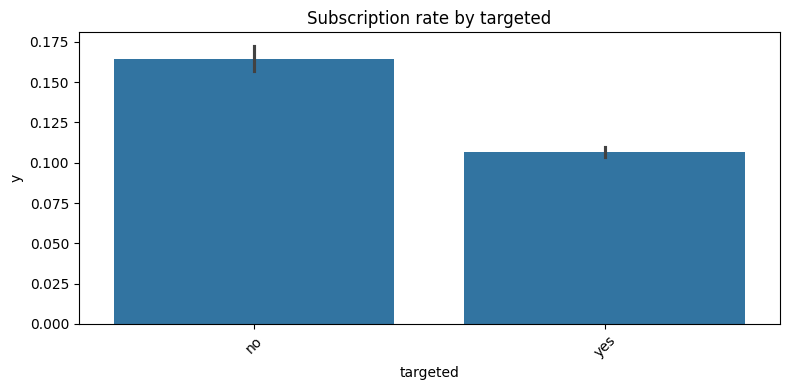

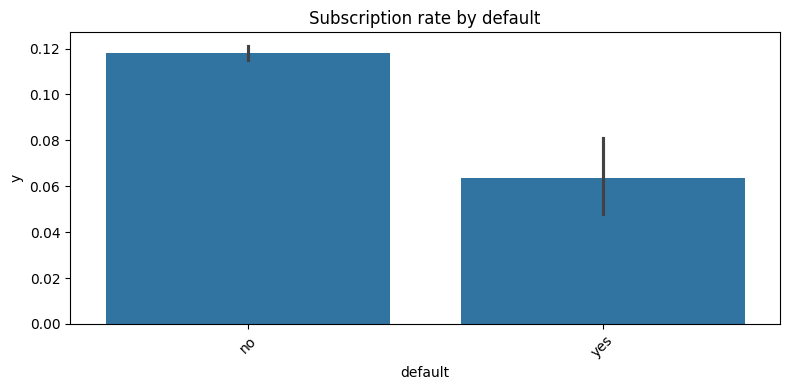

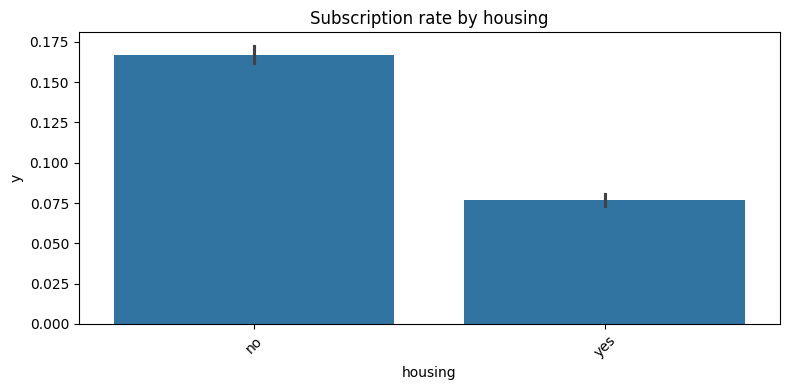

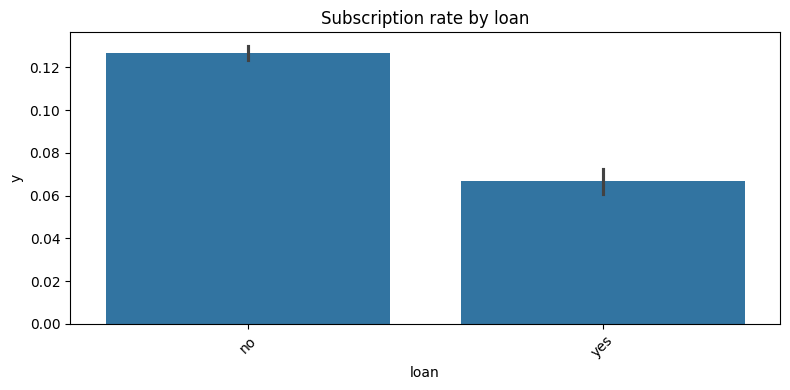

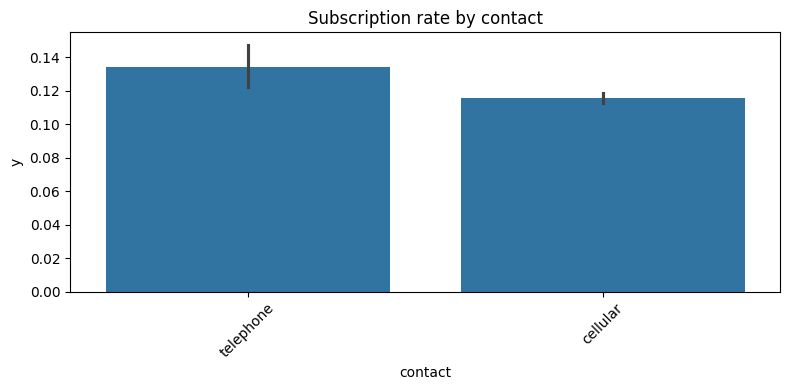

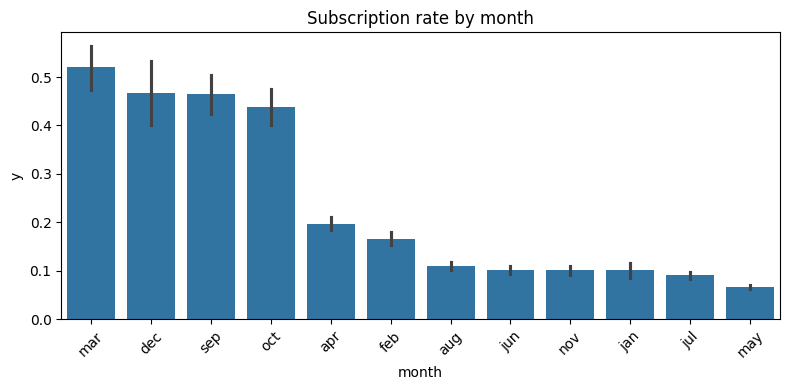

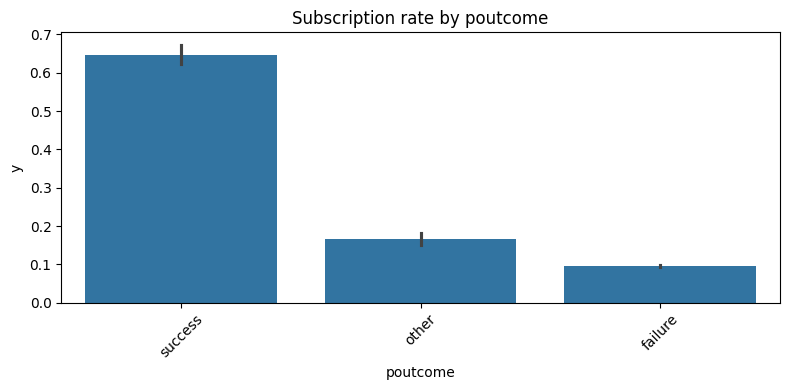

In [83]:
for col in CATEGORICAL_FEATURES[:-1]:   # Quitar variable target
    plt.figure(figsize=(8,4))

    # Calcular la tasa de suscripción promedio por categoría
    means = df.groupby(col)['y'].apply(lambda x: (x == 'yes').mean()).sort_values(ascending=False)

    sns.barplot(
        x=col,
        y=(df['y'] == 'yes').astype(int),
        data=df,
        estimator=np.mean,
        order=means.index
    )
    plt.title(f'Subscription rate by {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Matriz de correlación

In [117]:
correlation_matrix = df[num_cols + ['response']].corr()

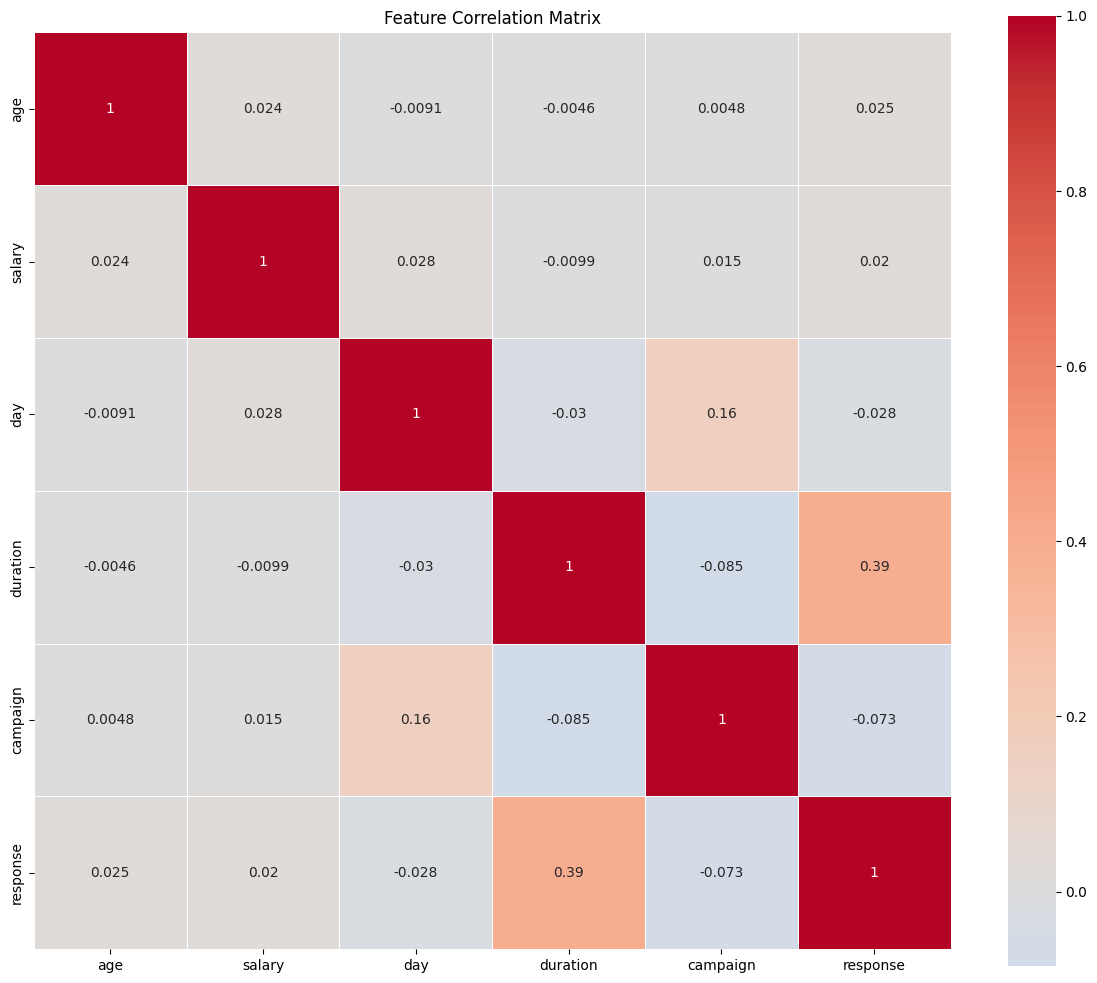

In [118]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [121]:
correlation_matrix['response'].abs().sort_values(ascending=False)[1:]

duration    0.394521
campaign    0.073172
day         0.028348
age         0.025155
salary      0.020012
Name: response, dtype: float64